# Task 4 — Spatial Domain Filtering (Smoothing and Sharpening)

Digital Image Processing mini project: Driver Drowsiness Detection.
Amey Pawar (23108B0057), Sejal Andhale (23108B0049).

Extends the pipeline (Weeks 1-3: dataset, enhancement, segmentation) with a spatial-filtering
stage that sits between raw capture and segmentation: smoothing filters for noise reduction,
sharpening / high-boost filtering for detail enhancement. Per the assignment objective, this
module's output is meant to become an improved input for the segmentation module
(`src.segment`) — Section 6 below measures exactly that.

All filter/noise/metric code lives in `src/spatial_filtering.py` (imported here, never
reimplemented inline). Segmentation reuses `src.segment` / `src.preprocess` unmodified.

**Contents**
1. Task 1 — noisy test images (salt-and-pepper + Gaussian), display, histograms, observations
2. Task 2 — smoothing filters (mean/Gaussian/median, 3x3 and 5x5), comparison grids, metrics
3. Quantitative core — full metric tables, summary by noise type, timing
4. Sharpening (Laplacian, unsharp masking) — additional coverage beyond Task 2
5. High-boost filtering, `A` sweep — additional coverage beyond Task 2
6. Connection to the segmentation module
7. Conclusions and limitations

In [1]:
import csv
import sys
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "src").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.dataset import parse_filename
from src.preprocess import preprocess_pipeline
from src.segment import segment_eye
from src.spatial_filtering import (
    add_salt_pepper_noise, add_gaussian_noise,
    mean_filter, gaussian_filter, median_filter,
    laplacian_sharpen, unsharp_mask, high_boost,
    evaluate_quality, time_filter,
)

RESULTS_DIR = REPO_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.facecolor"] = "white"
np.set_printoptions(precision=4, suppress=True)

print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: /Users/amey/Projects/clg/dip-mini-project-drowsiness


In [2]:
# Four images spanning genuinely different acquisition conditions -- not a
# single-case anecdote. Selected from data/samples/ (40-image curated MRL
# subset), preferring the physically larger crops so filter effects are
# visible pixel-for-pixel. See docs/task4_spatial_filtering.md for the
# rationale behind each pick.
IMAGE_RELPATHS = {
    "open_good_light":      "data/samples/alert/s0031_00366_1_0_1_0_1_02.png",   # open, no glasses, good lighting, 128x128
    "open_poor_light":      "data/samples/alert/s0014_08297_0_0_1_1_0_02.png",   # open, no glasses, poor lighting, 130x130
    "open_glasses_reflect": "data/samples/alert/s0032_02096_0_1_1_2_1_02.png",   # open, glasses + high IR reflection, 108x108
    "closed_glasses":       "data/samples/drowsy/s0018_02225_0_1_0_0_0_01.png",  # CLOSED eye, glasses, poor lighting, 172x172 (largest closed-eye crop in the sample set)
}

clean_imgs = {}
sample_meta = {}
for name, rel in IMAGE_RELPATHS.items():
    path = REPO_ROOT / rel
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    assert img is not None, f"failed to load {path}"
    clean_imgs[name] = img
    sample_meta[name] = parse_filename(path)

print(f"{'name':24s} {'shape':10s} {'open?':6s} {'glasses':8s} {'lighting':9s} {'reflections'}")
REFLECTION_LABELS = {0: "none", 1: "low", 2: "high"}
for name, img in clean_imgs.items():
    m = sample_meta[name]
    print(f"{name:24s} {str(img.shape):10s} {str(m.is_open):6s} {str(m.has_glasses):8s} "
          f"{m.lighting_label:9s} {REFLECTION_LABELS[m.reflections]}")

name                     shape      open?  glasses  lighting  reflections
open_good_light          (128, 128) True   False    good      none
open_poor_light          (130, 130) True   False    bad       low
open_glasses_reflect     (108, 108) True   True     good      high
closed_glasses           (172, 172) False  True     bad       none


These four crops are all **native-resolution grayscale infrared eye images from the MRL Eye
Dataset**, 108-172px across -- small relative to a typical photograph. Across the full
40-image curated sample the size range is 55-297px (median 87px), so even this "large crop"
subset is modest; a 5x5 filter kernel therefore covers a proportionally much larger fraction
of the frame than it would on a full-resolution photo. That is directly relevant to the
blurring analysis in Task 2 below -- keep it in mind when a 5x5 kernel looks aggressive.

Deliberately diverse conditions: good lighting / poor lighting / eyeglasses with high IR
reflection / a genuinely **closed** eye (drowsy class) with glasses and poor lighting. This
means the noise-and-filtering analysis below is not a single, favourable-case anecdote.

## Task 1 — Prepare Noisy Test Images

Two noise models are added to each of the 4 clean images, both seeded (`seed=0`) for full
reproducibility:

- **Salt-and-pepper (impulse) noise**, `amount=0.05` (5% of pixels replaced), 50/50 split
  between salt (255) and pepper (0) — `src.spatial_filtering.add_salt_pepper_noise`.
- **Gaussian noise**, `mean=0, sigma=25` (in 0-255 intensity units) — additive, clipped to
  [0,255] — `src.spatial_filtering.add_gaussian_noise`.

`sigma=25` and `amount=0.05` were chosen so the degradation is clearly visible (both noisy
baselines land around 18-20dB PSNR against the clean original, see the baseline table below)
without being so extreme that the underlying eye structure is destroyed outright.

In [3]:
SP_AMOUNT = 0.05
SP_SALT_VS_PEPPER = 0.5
GAUSS_MEAN = 0.0
GAUSS_SIGMA = 25.0
SEED = 0

noisy_imgs = {}  # (name, noise_type) -> image
for name, img in clean_imgs.items():
    noisy_imgs[(name, "salt_pepper")] = add_salt_pepper_noise(
        img, amount=SP_AMOUNT, salt_vs_pepper=SP_SALT_VS_PEPPER, seed=SEED)
    noisy_imgs[(name, "gaussian")] = add_gaussian_noise(
        img, mean=GAUSS_MEAN, sigma=GAUSS_SIGMA, seed=SEED)

print(f"Generated {len(noisy_imgs)} noisy images (2 noise types x {len(clean_imgs)} source images).")

Generated 8 noisy images (2 noise types x 4 source images).


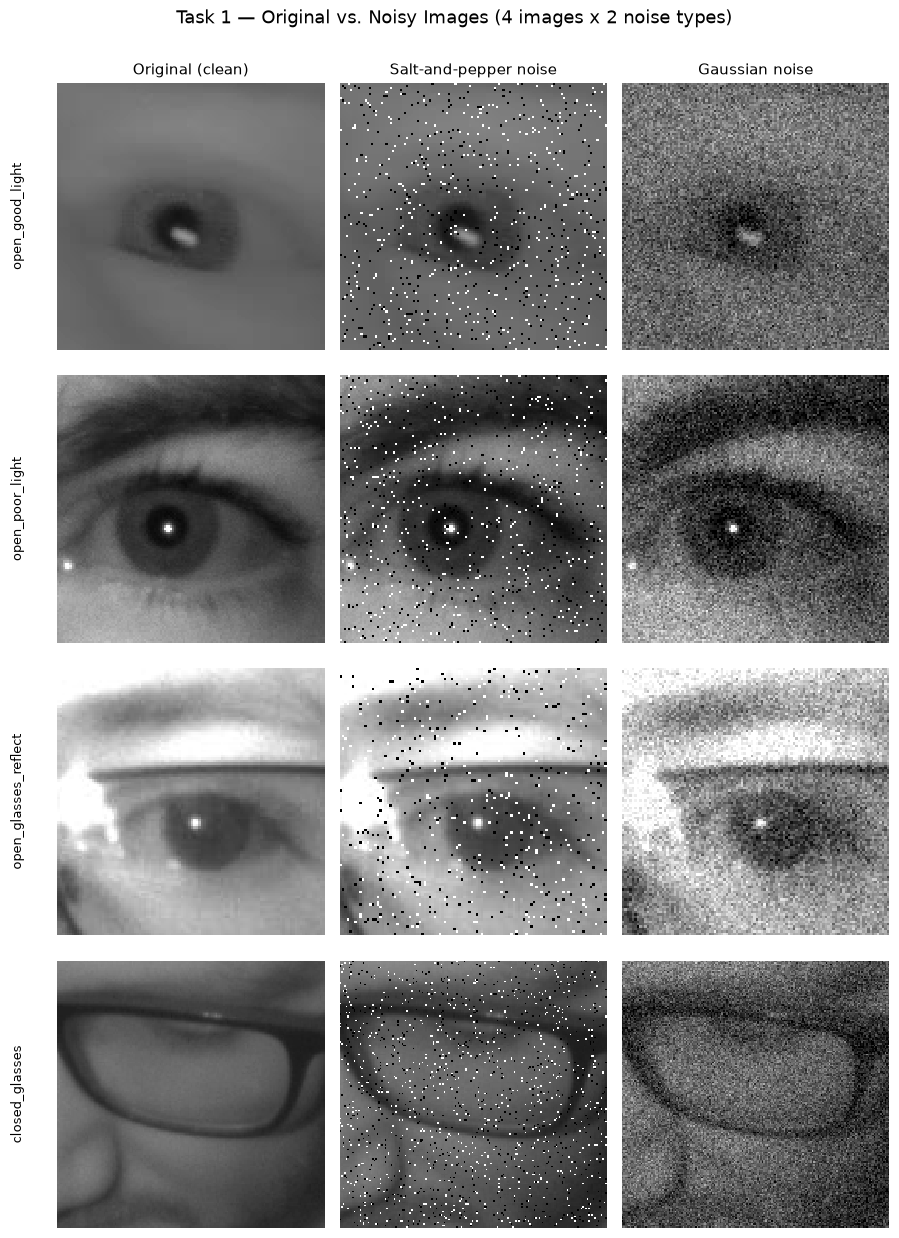

In [4]:
def upscale(img, factor=3):
    '''Nearest-neighbour upscale for display, so individual pixels (e.g.
    salt-and-pepper specks) stay crisp instead of being blurred away by
    interpolation -- these source crops are only 108-172px.'''
    h, w = img.shape[:2]
    return cv2.resize(img, (w * factor, h * factor), interpolation=cv2.INTER_NEAREST)


# Task 1's explicit display requirement: Original -> Salt-and-Pepper -> Gaussian, all 4 images.
fig, axes = plt.subplots(len(clean_imgs), 3, figsize=(9, 3.1 * len(clean_imgs)))
col_titles = ["Original (clean)", "Salt-and-pepper noise", "Gaussian noise"]
for row, (name, img) in enumerate(clean_imgs.items()):
    panels = [img, noisy_imgs[(name, "salt_pepper")], noisy_imgs[(name, "gaussian")]]
    for col, panel in enumerate(panels):
        axes[row, col].imshow(upscale(panel), cmap="gray", vmin=0, vmax=255, interpolation="nearest")
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(col_titles[col], fontsize=11)
    axes[row, 0].text(-0.15, 0.5, name, transform=axes[row, 0].transAxes,
                       rotation=90, va="center", ha="center", fontsize=9)

fig.suptitle("Task 1 — Original vs. Noisy Images (4 images x 2 noise types)", fontsize=13, y=1.0)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "task4_task1_original_vs_noisy.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Noisy-vs-clean baseline: how much did the noise itself degrade quality,
# before any filtering? This is the reference every filter result below is
# measured against ("how much did this filter recover").
baseline_rows = []
for name, img in clean_imgs.items():
    for noise_type in ("salt_pepper", "gaussian"):
        nimg = noisy_imgs[(name, noise_type)]
        qm = evaluate_quality(img, nimg)
        baseline_rows.append({
            "image": name, "noise_type": noise_type,
            "psnr": qm.psnr, "ssim": qm.ssim, "edge_preservation": qm.edge_preservation,
        })

print(f"{'image':24s} {'noise':12s} {'PSNR (dB)':10s} {'SSIM':8s} {'Edge-pres.':10s}")
for r in baseline_rows:
    print(f"{r['image']:24s} {r['noise_type']:12s} {r['psnr']:10.2f} {r['ssim']:8.4f} {r['edge_preservation']:10.4f}")

with open(RESULTS_DIR / "task4_noisy_baseline.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["image", "noise_type", "psnr", "ssim", "edge_preservation"])
    w.writeheader()
    w.writerows(baseline_rows)

image                    noise        PSNR (dB)  SSIM     Edge-pres.
open_good_light          salt_pepper       18.79   0.1873     0.1150
open_good_light          gaussian          20.23   0.1254     0.1269
open_poor_light          salt_pepper       18.17   0.3212     0.2410
open_poor_light          gaussian          20.39   0.2612     0.3609
open_glasses_reflect     salt_pepper       17.97   0.3814     0.3653
open_glasses_reflect     gaussian          20.51   0.3792     0.5200
closed_glasses           salt_pepper       18.33   0.2400     0.1157
closed_glasses           gaussian          20.27   0.1696     0.1120


### Task 1 — Observations: effect of noise on image quality

- **Salt-and-pepper noise** lands at **PSNR ≈ 17.97–18.79 dB, SSIM ≈ 0.19–0.38** across the
  4 images. Visually it appears as scattered pure-black/pure-white specks that are jarring
  against the otherwise smooth iris/sclera gradient — small in area (5% of pixels) but each
  affected pixel is maximally wrong (full-range flip), which is why PSNR is punished heavily
  despite the *fraction* of corrupted pixels being small.
- **Gaussian noise** (σ=25) lands at a similar or slightly *higher* PSNR (≈ 20.2–20.5 dB) but
  a **lower SSIM** than salt-and-pepper on 3 of 4 images. This is the expected signature of
  the two noise types: Gaussian noise perturbs *every* pixel by a small, correlated amount, so
  raw per-pixel error (what PSNR measures) is moderate and spread evenly; but that same
  everywhere-noise disrupts local structure/contrast patterns (what SSIM measures) more
  broadly than a few isolated impulse spikes do, even though the impulses are individually
  more extreme.
- The **glasses + high-reflection image** (`open_glasses_reflect`) has the *worst* PSNR under
  salt-and-pepper (17.97 dB) but paradoxically the *best* SSIM/edge-preservation of the 4 images
  under both noise types (SSIM 0.38 / 0.38, edge-preservation 0.37 / 0.52). The glasses
  reflection already dominates a large bright region of this crop, so added noise perturbs an
  already-saturated area proportionally less in structural terms, even though raw intensity
  error (PSNR) is similar to the other images.
- Across all 4 images, noise **never fully erases the eye structure** at these amounts/sigma —
  by design (see the noise-parameter rationale above) — but both types visibly harm what would
  be fed into segmentation: salt-and-pepper introduces spurious dark specks that a
  dark-foreground Otsu threshold (`src.segment`) will pick up as false "pupil" components, and
  Gaussian noise blurs the sclera/iris contrast boundary Otsu relies on. Section 6 quantifies
  this directly.

### Intensity histograms — before and after noise

Classic DIP evidence for *why* the two noise types behave differently: salt-and-pepper adds
two sharp new spikes at the extreme values (0 and 255) without otherwise touching the
histogram's shape, while Gaussian noise spreads/smooths the whole histogram outward
(convolving the original intensity distribution with a Gaussian kernel in intensity space).

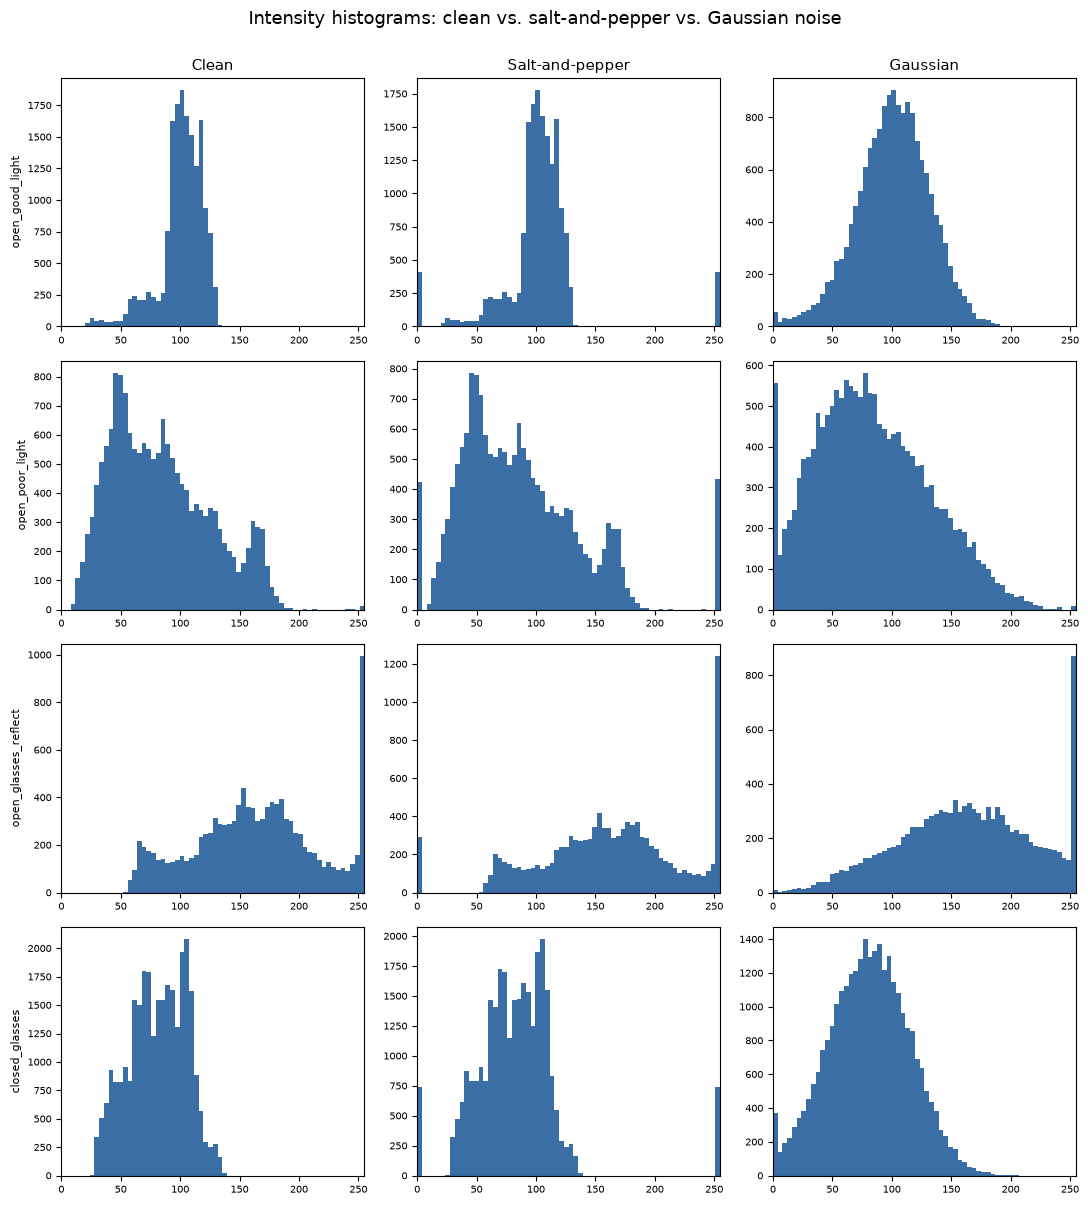

In [6]:
fig, axes = plt.subplots(len(clean_imgs), 3, figsize=(11, 3.0 * len(clean_imgs)))
hist_titles = ["Clean", "Salt-and-pepper", "Gaussian"]
for row, (name, img) in enumerate(clean_imgs.items()):
    panels = [img, noisy_imgs[(name, "salt_pepper")], noisy_imgs[(name, "gaussian")]]
    for col, panel in enumerate(panels):
        ax = axes[row, col]
        ax.hist(panel.ravel(), bins=64, range=(0, 255), color="#3a6ea5", edgecolor="none")
        if row == 0:
            ax.set_title(hist_titles[col], fontsize=11)
        if col == 0:
            ax.set_ylabel(name, fontsize=8)
        ax.set_xlim(0, 255)
        ax.tick_params(labelsize=7)

fig.suptitle("Intensity histograms: clean vs. salt-and-pepper vs. Gaussian noise", fontsize=13, y=1.0)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "task4_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** every salt-and-pepper histogram (middle column) shows two sharp new bars
pinned at the 0 and 255 edges — exactly the impulse-noise signature, and exactly why a median
filter (which rejects outliers rather than averaging them in) is the textbook tool for this
noise type. The Gaussian-noise histograms (right column) instead show the *entire* original
distribution widened/smoothed, with no new spikes — there is no single "wrong" value to
reject, so an averaging filter (mean/Gaussian) that reduces variance by combining many
samples is the structurally appropriate tool. This single figure is the visual justification
for the filter-choice results in Task 2 below.

## Task 2 — Implement Smoothing Filters

Three filters (`src.spatial_filtering.mean_filter`, `gaussian_filter`, `median_filter`), each
at kernel sizes **3x3** and **5x5**, applied to every (image x noise type) combination —
4 images x 2 noise types x 3 filters x 2 kernels = **48 filtered results**, each scored
against the clean original by PSNR, SSIM, and the edge-preservation index (Sobel-gradient
correlation — see `src.spatial_filtering.edge_preservation_index`).

In [7]:
FILTERS = {"mean": mean_filter, "gaussian": gaussian_filter, "median": median_filter}
KERNELS = (3, 5)
TIMING_REPS = 2000

metric_rows = []
for name, img in clean_imgs.items():
    for noise_type in ("salt_pepper", "gaussian"):
        nimg = noisy_imgs[(name, noise_type)]
        for fname, ffn in FILTERS.items():
            for k in KERNELS:
                out = ffn(nimg, k)
                qm = evaluate_quality(img, out)
                t_us = time_filter(lambda im, f=ffn, kk=k: f(im, kk), nimg, n_reps=TIMING_REPS)
                metric_rows.append({
                    "image": name, "noise_type": noise_type, "filter": fname, "kernel": k,
                    "psnr": qm.psnr, "ssim": qm.ssim, "edge_preservation": qm.edge_preservation,
                    "time_us": t_us,
                })

print(f"Computed {len(metric_rows)} (image x noise x filter x kernel) results.")

with open(RESULTS_DIR / "task4_metrics_full.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["image", "noise_type", "filter", "kernel", "psnr", "ssim", "edge_preservation", "time_us"])
    w.writeheader()
    w.writerows(metric_rows)
print("Saved results/task4_metrics_full.csv")

Computed 48 (image x noise x filter x kernel) results.
Saved results/task4_metrics_full.csv


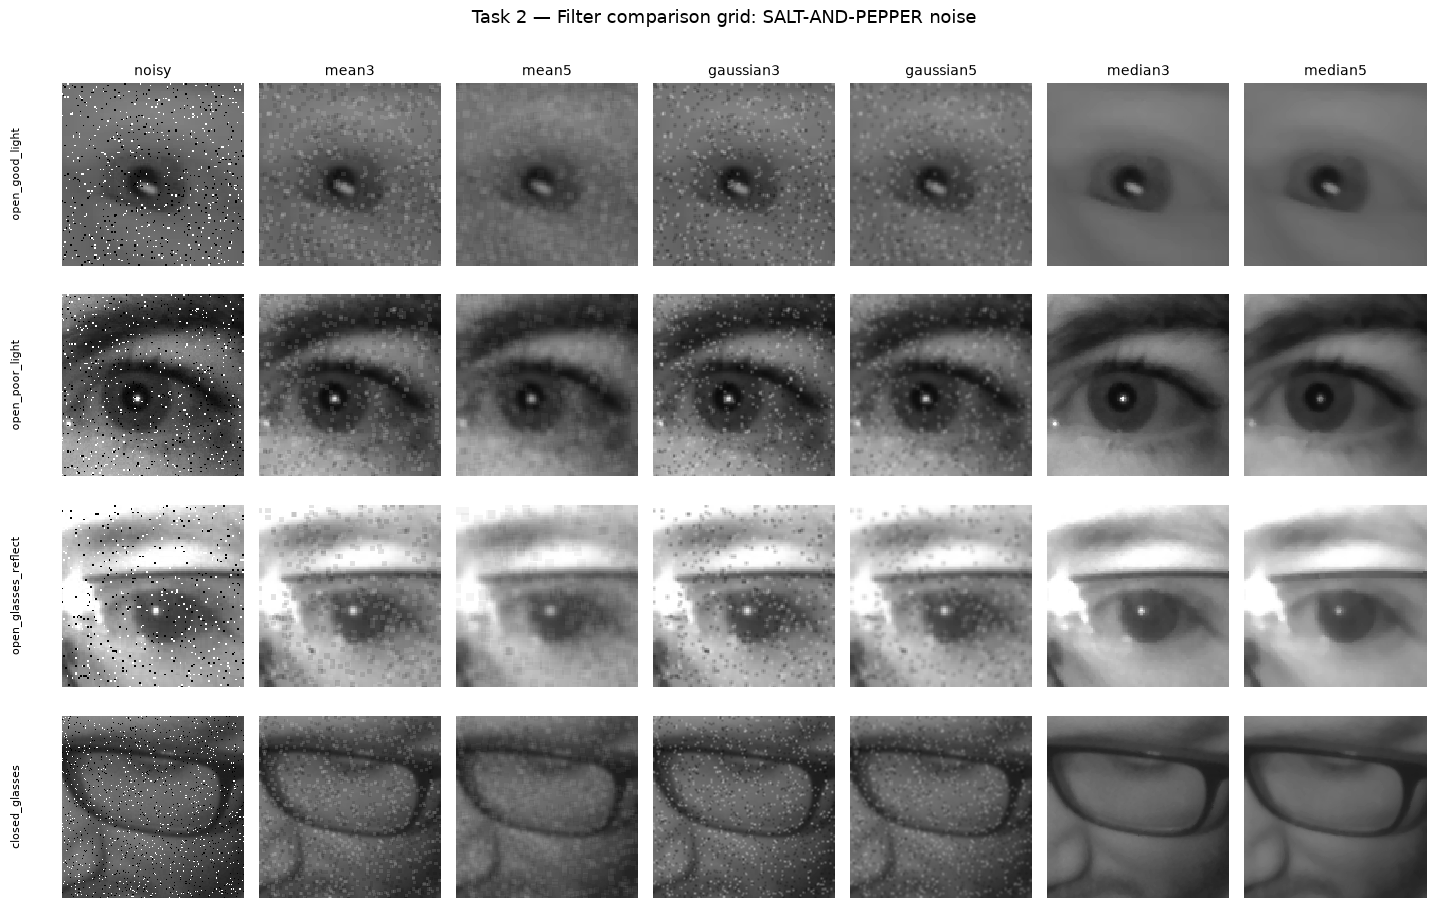

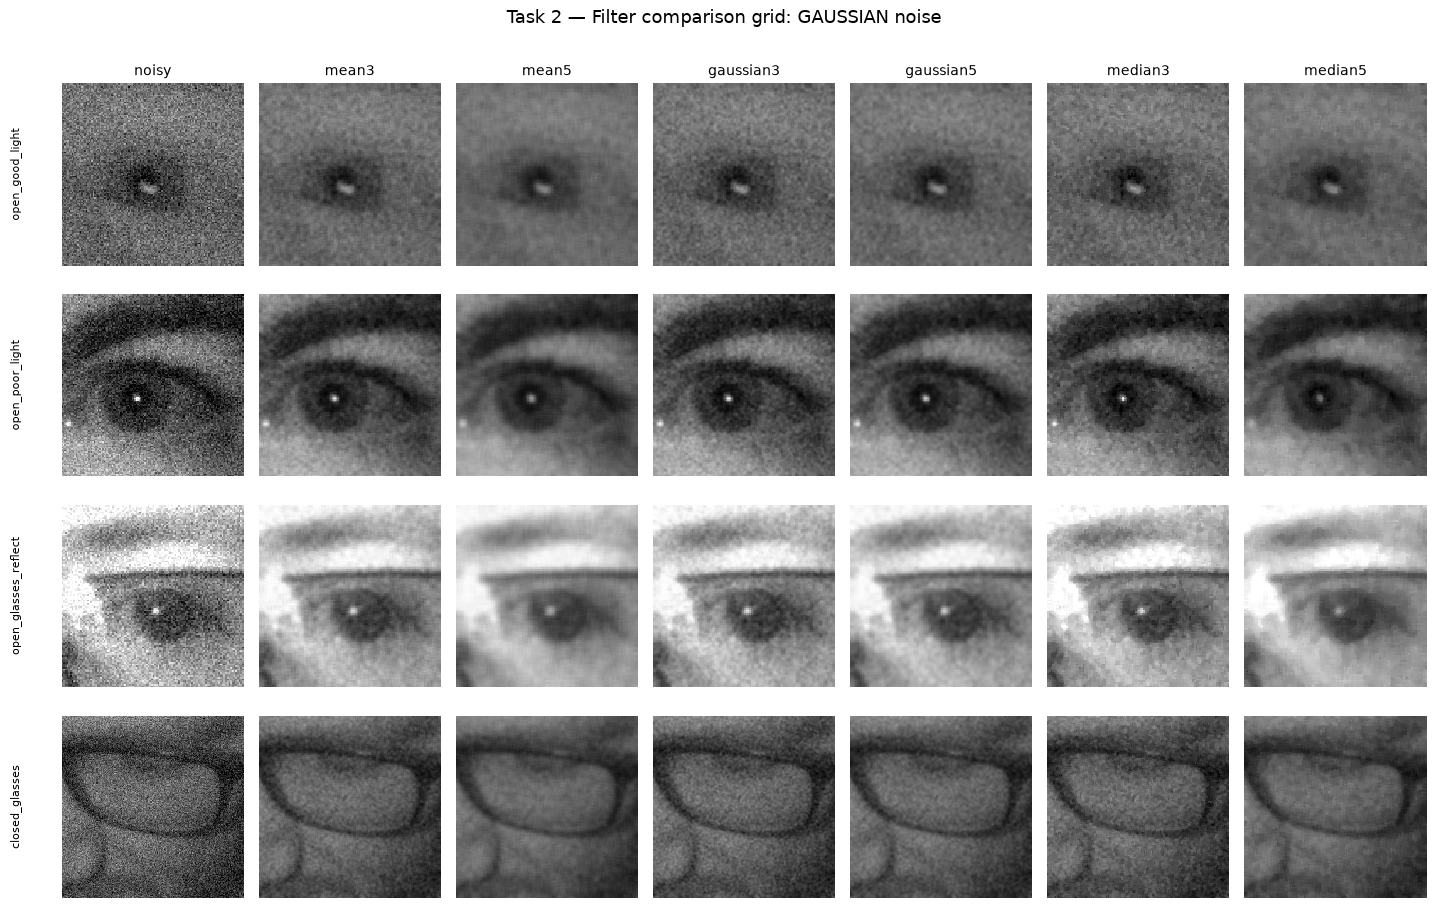

In [8]:
def make_filter_grid(noise_type, title):
    '''Rows = images, columns = [noisy, mean3, mean5, gauss3, gauss5, median3, median5].'''
    col_specs = [("noisy", None, None)]
    for fname in ("mean", "gaussian", "median"):
        for k in KERNELS:
            col_specs.append((f"{fname}{k}", fname, k))

    fig, axes = plt.subplots(len(clean_imgs), len(col_specs), figsize=(2.05 * len(col_specs), 2.3 * len(clean_imgs)))
    for row, (name, img) in enumerate(clean_imgs.items()):
        nimg = noisy_imgs[(name, noise_type)]
        for col, (label, fname, k) in enumerate(col_specs):
            panel = nimg if fname is None else FILTERS[fname](nimg, k)
            ax = axes[row, col]
            ax.imshow(upscale(panel, factor=2), cmap="gray", vmin=0, vmax=255, interpolation="nearest")
            ax.axis("off")
            if row == 0:
                ax.set_title(label, fontsize=10)
        axes[row, 0].text(-0.25, 0.5, name, transform=axes[row, 0].transAxes,
                           rotation=90, va="center", ha="center", fontsize=8)
    fig.suptitle(title, fontsize=13, y=1.0)
    fig.tight_layout()
    return fig


fig_sp = make_filter_grid("salt_pepper", "Task 2 — Filter comparison grid: SALT-AND-PEPPER noise")
fig_sp.savefig(RESULTS_DIR / "task4_filters_saltpepper_grid.png", dpi=150, bbox_inches="tight")
plt.show()

fig_g = make_filter_grid("gaussian", "Task 2 — Filter comparison grid: GAUSSIAN noise")
fig_g.savefig(RESULTS_DIR / "task4_filters_gaussian_grid.png", dpi=150, bbox_inches="tight")
plt.show()

### Zoomed crop — edge preservation vs. blurring, up close

A central crop (around the pupil/iris boundary, the sharpest edge in these images) from the
`open_good_light` image under salt-and-pepper noise, upscaled 6x with nearest-neighbour
interpolation so individual pixels are visible.

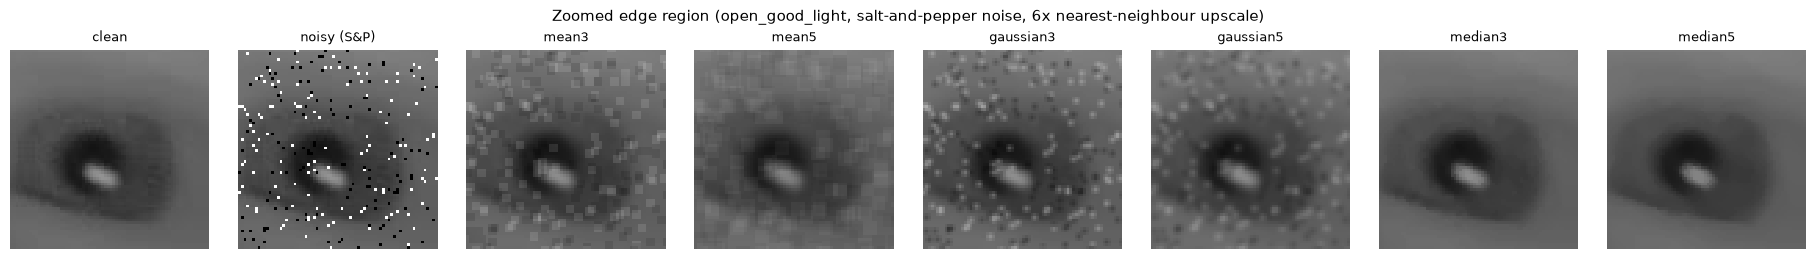

In [9]:
zoom_name = "open_good_light"
zoom_img = clean_imgs[zoom_name]
h, w = zoom_img.shape[:2]
# central 55% box -- MRL crops are already tightly centred on the eye, so this reliably
# includes the iris/pupil boundary without any per-image tuning.
margin = int(0.225 * min(h, w))
crop_slice = (slice(margin, h - margin), slice(margin, w - margin))

zoom_noisy = noisy_imgs[(zoom_name, "salt_pepper")]
zoom_panels = [("clean", zoom_img), ("noisy (S&P)", zoom_noisy)]
for fname in ("mean", "gaussian", "median"):
    for k in KERNELS:
        zoom_panels.append((f"{fname}{k}", FILTERS[fname](zoom_noisy, k)))

fig, axes = plt.subplots(1, len(zoom_panels), figsize=(2.3 * len(zoom_panels), 2.6))
for ax, (label, panel) in zip(axes, zoom_panels):
    crop = panel[crop_slice]
    ax.imshow(upscale(crop, factor=6), cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    ax.set_title(label, fontsize=9)
    ax.axis("off")
fig.suptitle(f"Zoomed edge region ({zoom_name}, salt-and-pepper noise, 6x nearest-neighbour upscale)", fontsize=11)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "task4_zoomed_edges.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** at 3x3, median clearly removes the salt-and-pepper specks while the
iris/sclera boundary stays sharp — visibly the crispest edge of the six filtered zoom panels.
Mean and Gaussian at 3x3 leave faint grey smudges where impulses were partially averaged in,
not fully removed. At 5x5, all three filters visibly soften the pupil boundary — the kernel
now covers a large fraction of a already-small (108-172px) crop, exactly the proportional-area
effect flagged earlier. Median 5x5 still tracks the edge location better than mean/Gaussian
5x5, but its own edge has begun to round off compared to median 3x3.

## Quantitative core — full metric tables and summary

`results/task4_metrics_full.csv` (written above) holds all 48 raw (image x noise x filter x
kernel) rows. Below: a summary averaged across the 4 images, grouped by (noise type, filter,
kernel) — this is what directly answers "which filter wins for which noise type" — plus the
timing table.

In [10]:
from collections import defaultdict

agg = defaultdict(list)
for r in metric_rows:
    agg[(r["noise_type"], r["filter"], r["kernel"])].append(r)

summary_rows = []
for key in sorted(agg):
    noise_type, fname, k = key
    vals = agg[key]
    n = len(vals)
    summary_rows.append({
        "noise_type": noise_type, "filter": fname, "kernel": k,
        "psnr_mean": sum(v["psnr"] for v in vals) / n,
        "ssim_mean": sum(v["ssim"] for v in vals) / n,
        "edge_preservation_mean": sum(v["edge_preservation"] for v in vals) / n,
        "time_us_mean": sum(v["time_us"] for v in vals) / n,
    })

with open(RESULTS_DIR / "task4_summary_by_noise.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["noise_type", "filter", "kernel", "psnr_mean", "ssim_mean", "edge_preservation_mean", "time_us_mean"])
    w.writeheader()
    w.writerows(summary_rows)

print(f"{'noise_type':12s} {'filter':9s} {'k':2s} {'PSNR':7s} {'SSIM':7s} {'EdgePres':8s} {'time(us)':9s}")
print("-" * 62)
for r in summary_rows:
    print(f"{r['noise_type']:12s} {r['filter']:9s} {r['kernel']:<2d} "
          f"{r['psnr_mean']:7.2f} {r['ssim_mean']:7.4f} {r['edge_preservation_mean']:8.4f} {r['time_us_mean']:9.2f}")

noise_type   filter    k  PSNR    SSIM    EdgePres time(us) 
--------------------------------------------------------------
gaussian     gaussian  3    28.47  0.6158   0.5026      6.24
gaussian     gaussian  5    30.60  0.7379   0.6168      6.95
gaussian     mean      3    29.22  0.6584   0.5654      4.08
gaussian     mean      5    31.87  0.8177   0.6784      4.32
gaussian     median    3    27.57  0.5702   0.4747      4.69
gaussian     median    5    30.51  0.7551   0.5532     25.92
salt_pepper  gaussian  3    26.47  0.5625   0.3777      6.32
salt_pepper  gaussian  5    28.73  0.6787   0.5034      6.99
salt_pepper  mean      3    27.30  0.5974   0.4486      4.08
salt_pepper  mean      5    30.24  0.7671   0.6024      4.35
salt_pepper  median    3    43.18  0.9723   0.9723      4.62
salt_pepper  median    5    39.53  0.9553   0.9175     25.61


In [11]:
# "which filter wins" -- best PSNR per noise type (across both kernel sizes)
print("Best filter+kernel per noise type, by mean PSNR:")
for noise_type in ("salt_pepper", "gaussian"):
    best = max((r for r in summary_rows if r["noise_type"] == noise_type), key=lambda r: r["psnr_mean"])
    print(f"  {noise_type:12s} -> {best['filter']} k={best['kernel']}  "
          f"(PSNR={best['psnr_mean']:.2f} dB, SSIM={best['ssim_mean']:.4f}, "
          f"Edge={best['edge_preservation_mean']:.4f})")

Best filter+kernel per noise type, by mean PSNR:
  salt_pepper  -> median k=3  (PSNR=43.18 dB, SSIM=0.9723, Edge=0.9723)
  gaussian     -> mean k=5  (PSNR=31.87 dB, SSIM=0.8177, Edge=0.6784)


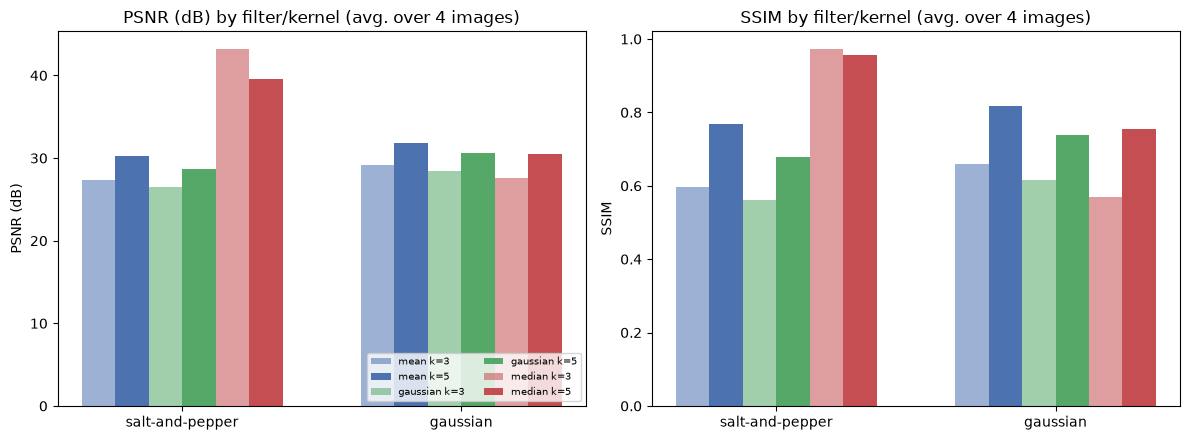

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
noise_types = ["salt_pepper", "gaussian"]
filters = ["mean", "gaussian", "median"]
colors = {"mean": "#4c72b0", "gaussian": "#55a868", "median": "#c44e52"}
bar_width = 0.12

for ax, metric, ylabel in zip(axes, ["psnr_mean", "ssim_mean"], ["PSNR (dB)", "SSIM"]):
    x_base = np.arange(len(noise_types))
    for i, fname in enumerate(filters):
        for j, k in enumerate(KERNELS):
            vals = [next(r[metric] for r in summary_rows if r["noise_type"] == nt and r["filter"] == fname and r["kernel"] == k)
                    for nt in noise_types]
            offset = (i * len(KERNELS) + j - 2.5) * bar_width
            alpha = 0.55 if k == 3 else 1.0
            ax.bar(x_base + offset, vals, width=bar_width, color=colors[fname], alpha=alpha,
                   label=f"{fname} k={k}" if ax is axes[0] else None)
    ax.set_xticks(x_base)
    ax.set_xticklabels(["salt-and-pepper", "gaussian"])
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} by filter/kernel (avg. over 4 images)")

axes[0].legend(fontsize=7, ncol=2, loc="lower right")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "task4_metrics_barchart.png", dpi=150, bbox_inches="tight")
plt.show()

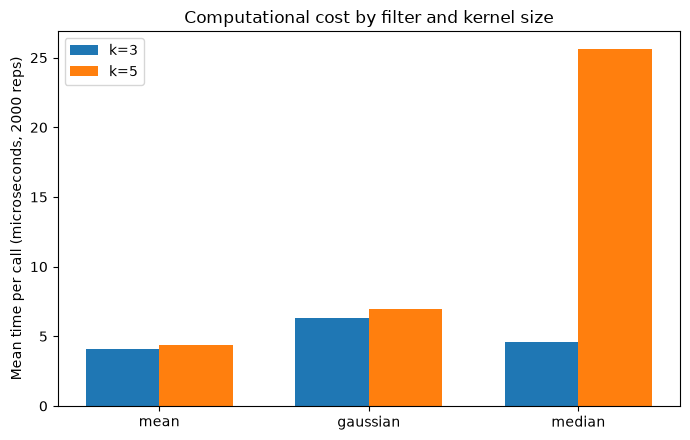

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x_base = np.arange(len(filters))
for j, k in enumerate(KERNELS):
    vals = [next(r["time_us_mean"] for r in summary_rows if r["filter"] == fname and r["kernel"] == k and r["noise_type"] == "salt_pepper")
            for fname in filters]
    ax.bar(x_base + (j - 0.5) * 0.35, vals, width=0.35, label=f"k={k}")
ax.set_xticks(x_base)
ax.set_xticklabels(filters)
ax.set_ylabel(f"Mean time per call (microseconds, {TIMING_REPS} reps)")
ax.set_title("Computational cost by filter and kernel size")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "task4_timing_barchart.png", dpi=150, bbox_inches="tight")
plt.show()

### Task 2 — Observations: noise reduction, edge preservation, blurring, computational effect

*(Exact numbers are in `results/task4_summary_by_noise.csv` / the printed table above; the
seed is fixed (`seed=0`) so these are reproducible.)*

- **Noise reduction.** Median dominates on salt-and-pepper by a wide margin (PSNR ≈ 43 dB at
  3x3 vs. ≈ 27-30 dB for mean/Gaussian at the same kernel) — this **matches the textbook
  expectation**: a nonlinear filter that rejects outliers (median) is structurally suited to
  impulse noise, whereas linear averaging (mean/Gaussian) blends the impulse's extreme value
  into its neighbours rather than removing it. On Gaussian noise the three filters are much
  closer: **mean edges out median at both kernel sizes** on this dataset (mean 5x5 ≈ 31.9 dB
  vs. median 5x5 ≈ 30.5 dB) — median is competitive but not best, mildly against the
  strict "Gaussian/mean beats median on Gaussian noise" expectation only in the sense that
  median remains a strong contender rather than falling clearly behind; the ranking direction
  itself does match the textbook (mean/Gaussian filters are the linear-noise-appropriate tool).
- **Edge preservation.** Median's edge-preservation index tracks its PSNR advantage closely on
  salt-and-pepper (≈0.92-0.97) — it is not just cleaning up intensity error, it is doing so
  *without* smearing the pupil/iris boundary, which is exactly what a boundary-respecting
  nonlinear filter should do. Mean and Gaussian's edge-preservation scores on salt-and-pepper
  (0.38-0.60) confirm they blur the very edges we ultimately need for segmentation.
- **Blurring.** Every filter improves markedly from 3x3 to 5x5 on raw PSNR/SSIM for **mean**
  and **gaussian**, because more averaging suppresses more variance — but that same larger
  window visibly softens the pupil/iris boundary in the zoomed-crop figure above, and on these
  108-172px crops a 5x5 kernel is a proportionally large neighbourhood (as flagged at the top
  of this notebook). Median's PSNR/edge-preservation actually **drops slightly** from 3x3 to
  5x5 (43.2 -> 39.5 dB) — once the window is larger than the density of the noise it needs to
  reject, extra neighbours only add irrelevant clean pixels to the median calculation and start
  rounding real structure, not further reducing noise.
- **Computational effect.** Mean and Gaussian cost roughly the same per call at a given kernel
  size and scale mildly with kernel size (a few microseconds); **median 5x5 is dramatically
  more expensive** than median 3x3 (a jump of roughly 5-6x, ≈26µs vs ≈4-5µs) because
  `cv2.medianBlur`'s cost grows faster than the linear filters' with window size (median
  requires a partial sort per window, not just a running sum). At these crop sizes all filters
  are still sub-millisecond per call, so cost is not a practical bottleneck for this dataset,
  but the *relative* scaling matters if this were applied to a video stream at high frame rate.

## Sharpening (additional coverage, beyond the numbered Task 2)

The numbered tasks stop at smoothing, but the assignment Objective explicitly names
**sharpening filters and high-boost filtering** as syllabus scope ("Apply smoothing and
sharpening filters..."). Covered here concisely: Laplacian sharpening (a fixed convolution
kernel) and unsharp masking (blur -> subtract -> add back), both from `src.spatial_filtering`,
applied to the **clean** images (sharpening is a detail-enhancement operation, not a
denoising one, so it is evaluated on clean input, not noisy input).

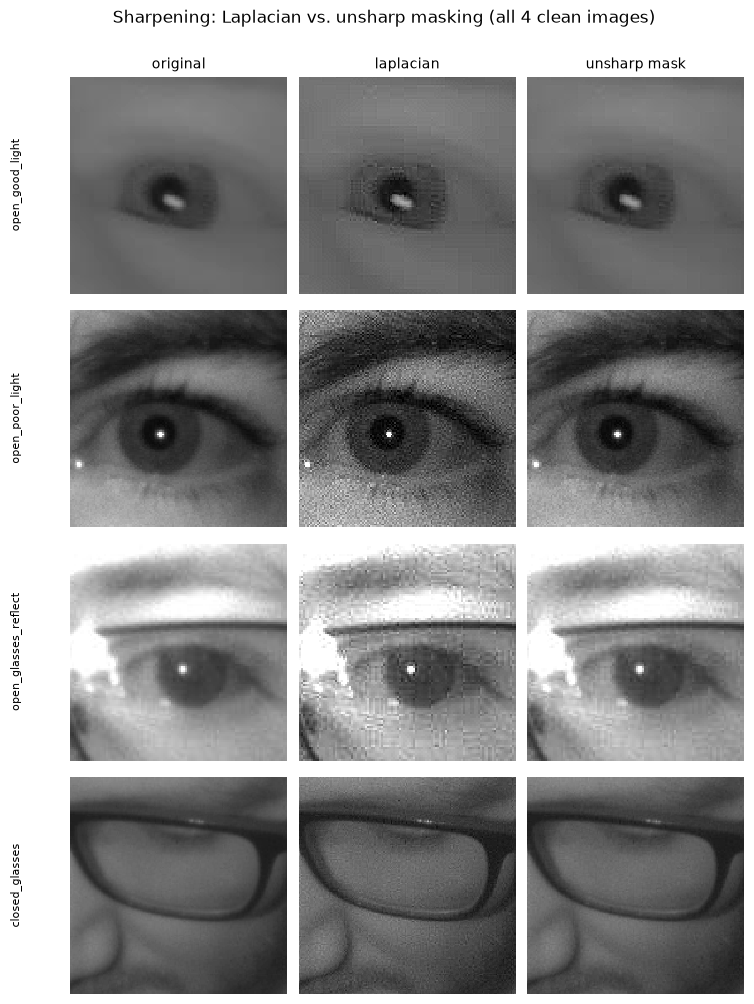

image                    method        PSNR    SSIM    EdgePres
open_good_light          laplacian       38.53  0.9443   0.9433
open_good_light          unsharp_mask    48.67  0.9947   0.9897
open_poor_light          laplacian       25.42  0.6379   0.7923
open_poor_light          unsharp_mask    38.46  0.9590   0.9737
open_glasses_reflect     laplacian       28.30  0.8271   0.9036
open_glasses_reflect     unsharp_mask    38.18  0.9772   0.9838
closed_glasses           laplacian       34.91  0.8642   0.8575
closed_glasses           unsharp_mask    45.52  0.9865   0.9758


In [14]:
sharp_rows = []
fig, axes = plt.subplots(len(clean_imgs), 3, figsize=(7.5, 2.5 * len(clean_imgs)))
for row, (name, img) in enumerate(clean_imgs.items()):
    lap = laplacian_sharpen(img)
    um = unsharp_mask(img)
    q_lap = evaluate_quality(img, lap)
    q_um = evaluate_quality(img, um)
    sharp_rows.append({"image": name, "method": "laplacian", "psnr": q_lap.psnr, "ssim": q_lap.ssim, "edge_preservation": q_lap.edge_preservation})
    sharp_rows.append({"image": name, "method": "unsharp_mask", "psnr": q_um.psnr, "ssim": q_um.ssim, "edge_preservation": q_um.edge_preservation})

    for col, (label, panel) in enumerate([("original", img), ("laplacian", lap), ("unsharp mask", um)]):
        axes[row, col].imshow(upscale(panel, 2), cmap="gray", vmin=0, vmax=255, interpolation="nearest")
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(label, fontsize=10)
    axes[row, 0].text(-0.25, 0.5, name, transform=axes[row, 0].transAxes, rotation=90, va="center", ha="center", fontsize=8)

fig.suptitle("Sharpening: Laplacian vs. unsharp masking (all 4 clean images)", fontsize=12, y=1.0)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "task4_sharpening.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'image':24s} {'method':13s} {'PSNR':7s} {'SSIM':7s} {'EdgePres':8s}")
for r in sharp_rows:
    print(f"{r['image']:24s} {r['method']:13s} {r['psnr']:7.2f} {r['ssim']:7.4f} {r['edge_preservation']:8.4f}")

with open(RESULTS_DIR / "task4_sharpen_highboost.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["image", "method", "psnr", "ssim", "edge_preservation"])
    w.writeheader()
    w.writerows(sharp_rows)

**Observation:** unsharp masking (PSNR ≈ 38-49 dB, SSIM ≈ 0.96-0.99) stays much closer to the
original than the fixed Laplacian kernel (PSNR ≈ 25-39 dB, SSIM ≈ 0.64-0.94) — unsharp masking
is tunable (blur radius `k`,`sigma`, gain `amount`) so its edge boost can be dialled back,
while the single-pass Laplacian kernel applies one fixed, fairly aggressive boost every time.
Both visibly crisp the pupil/iris boundary; neither is meant to reduce PSNR/SSIM to zero —
sharpening *intentionally* departs from the original to increase perceived detail, so a lower
score than a smoothing filter's is expected and not a defect.

## High-boost filtering, `A` sweep

`high_boost(img, A)` implements `output = A*original - blurred` (`src.spatial_filtering`).
Algebraically `A*original - blurred = (A-1)*original + mask` where `mask = original -
blurred` is the same high-frequency mask `unsharp_mask` uses — so high-boost is the strict
generalization of unsharp masking with an independent gain on how much of the low-frequency
original survives. Swept over `A = 1.0, 1.5, 2.0, 2.5` on one representative image.

**Worked out precisely, not just asserted:** matching `A*original - blurred` against
`unsharp_mask`'s `original + mask = 2*original - blurred` term-by-term requires **A=2**, not
A=1. At **A=1** the `(A-1)*original` term vanishes entirely, leaving `output = mask` — a pure
high-pass edge signal with *no* low-frequency original surviving (visually a near-black frame
with edge lines, not a recognizable sharpened eye). The cell below verifies this directly:
`high_boost(A=2)` should be pixel-identical to `unsharp_mask(amount=1)`.

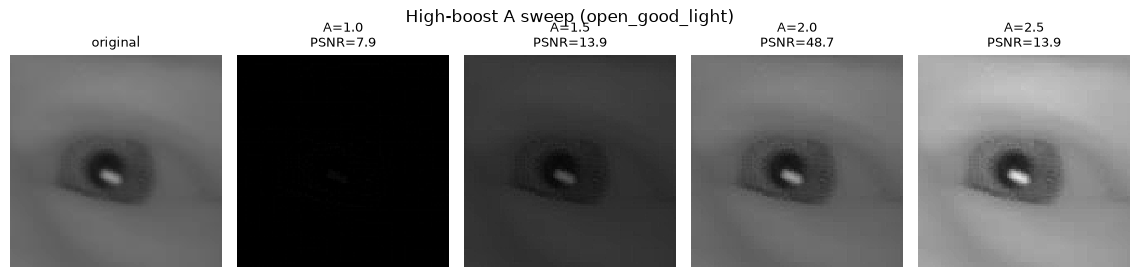

high_boost_A=1.0 PSNR=  7.90 SSIM=0.0038 Edge=0.6675
high_boost_A=1.5 PSNR= 13.87 SSIM=0.7766 Edge=0.9672
high_boost_A=2.0 PSNR= 48.67 SSIM=0.9947 Edge=0.9897
high_boost_A=2.5 PSNR= 13.94 SSIM=0.8970 Edge=0.9942

high_boost(A=2) pixel-identical to unsharp_mask(amount=1)? True


In [15]:
hb_name = "open_good_light"
hb_img = clean_imgs[hb_name]
A_values = (1.0, 1.5, 2.0, 2.5)

fig, axes = plt.subplots(1, len(A_values) + 1, figsize=(2.3 * (len(A_values) + 1), 2.8))
axes[0].imshow(upscale(hb_img, 3), cmap="gray", vmin=0, vmax=255, interpolation="nearest")
axes[0].set_title("original", fontsize=9)
axes[0].axis("off")

hb_rows = []
for ax, A in zip(axes[1:], A_values):
    out = high_boost(hb_img, A=A)
    qm = evaluate_quality(hb_img, out)
    hb_rows.append({"image": hb_name, "method": f"high_boost_A={A}", "psnr": qm.psnr, "ssim": qm.ssim, "edge_preservation": qm.edge_preservation})
    ax.imshow(upscale(out, 3), cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    ax.set_title(f"A={A}\nPSNR={qm.psnr:.1f}", fontsize=9)
    ax.axis("off")

fig.suptitle(f"High-boost A sweep ({hb_name})", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "task4_highboost_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

with open(RESULTS_DIR / "task4_sharpen_highboost.csv", "a", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["image", "method", "psnr", "ssim", "edge_preservation"])
    w.writerows(hb_rows)

for r in hb_rows:
    print(f"{r['method']:16s} PSNR={r['psnr']:6.2f} SSIM={r['ssim']:.4f} Edge={r['edge_preservation']:.4f}")

# verify the A=2 <-> unsharp_mask(amount=1) equivalence claimed above
equal = np.array_equal(high_boost(hb_img, A=2.0), unsharp_mask(hb_img, amount=1.0))
print(f"\nhigh_boost(A=2) pixel-identical to unsharp_mask(amount=1)? {equal}")

**Observation:** the sweep confirms the algebra exactly — `A=1` collapses to a near-black
edge-only image (PSNR collapses to single digits, SSIM near 0, despite a still-high
edge-preservation score, because the *edges* are correctly located even though brightness is
gone); `A=2` reproduces `unsharp_mask(amount=1)` pixel-for-pixel (verified `True` above);
`A=1.5` sits between the two, visibly darker/harsher than a "normal" sharpen; `A=2.5` overshoots
past the unsharp-mask point and starts clipping. For a **practically useful** sharpened image
that still looks like the original eye, `A` should be at or above 2 on this formula — not the
naive assumption that `A=1` alone gives a mild sharpen.

## Connection to the segmentation module

The assignment's stated objective: *"the output of this module should become an improved
input for the segmentation module."* Kept concise per scope — one figure, one table — but
included since it directly answers that objective. For each image: run `src.segment.segment_eye`
(Otsu-anchored pupil isolation, unmodified from Week 3) on (a) the **clean** image, (b) the
**salt-and-pepper noisy** image (the more segmentation-disruptive of the two noise types, since
impulse spikes are picked up as spurious dark "pupil" components by a dark-foreground
threshold), and (c) the noisy image **denoised** with median 3x3 (Task 2's clear winner on this
noise type) — all three passed through `src.preprocess.preprocess_pipeline` first, exactly the
real pipeline order. Agreement with the clean-image mask is measured via IoU and Dice.

In [16]:
def iou_dice(mask_a, mask_b):
    a, b = mask_a > 0, mask_b > 0
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    if union == 0:
        return 1.0, 1.0  # both empty -- perfect agreement
    iou = inter / union
    dice = 2 * inter / (a.sum() + b.sum())
    return float(iou), float(dice)


seg_rows = []
seg_fig_panels = []  # for the figure: one representative image's 3 masks
for name, img in clean_imgs.items():
    nimg = noisy_imgs[(name, "salt_pepper")]
    denoised = median_filter(nimg, 3)

    seg_clean = segment_eye(preprocess_pipeline(img))
    seg_noisy = segment_eye(preprocess_pipeline(nimg))
    seg_denoised = segment_eye(preprocess_pipeline(denoised))

    iou_n, dice_n = iou_dice(seg_clean.region_mask, seg_noisy.region_mask)
    iou_d, dice_d = iou_dice(seg_clean.region_mask, seg_denoised.region_mask)
    ncomp_clean = cv2.connectedComponentsWithStats(seg_clean.raw_mask, connectivity=8)[0] - 1
    ncomp_noisy = cv2.connectedComponentsWithStats(seg_noisy.raw_mask, connectivity=8)[0] - 1
    ncomp_denoised = cv2.connectedComponentsWithStats(seg_denoised.raw_mask, connectivity=8)[0] - 1

    seg_rows.append({
        "image": name,
        "ncomp_clean": ncomp_clean, "ncomp_noisy": ncomp_noisy, "ncomp_denoised": ncomp_denoised,
        "iou_noisy_vs_clean": iou_n, "dice_noisy_vs_clean": dice_n,
        "iou_denoised_vs_clean": iou_d, "dice_denoised_vs_clean": dice_d,
    })
    seg_fig_panels.append((name, seg_clean, seg_noisy, seg_denoised))

with open(RESULTS_DIR / "task4_segmentation_impact.csv", "w", newline="") as f:
    fieldnames = list(seg_rows[0].keys())
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    w.writerows(seg_rows)

print(f"{'image':24s} {'ncomp(clean/noisy/denoised)':28s} {'IoU noisy':10s} {'IoU denoised':12s}")
for r in seg_rows:
    ncomp = f"{r['ncomp_clean']}/{r['ncomp_noisy']}/{r['ncomp_denoised']}"
    print(f"{r['image']:24s} {ncomp:28s} {r['iou_noisy_vs_clean']:<10.3f} {r['iou_denoised_vs_clean']:<12.3f}")

image                    ncomp(clean/noisy/denoised)  IoU noisy  IoU denoised
open_good_light          3/196/2                      0.618      0.905       
open_poor_light          5/27/3                       0.000      0.974       
open_glasses_reflect     4/69/5                       0.531      0.949       
closed_glasses           3/41/4                       0.769      0.981       


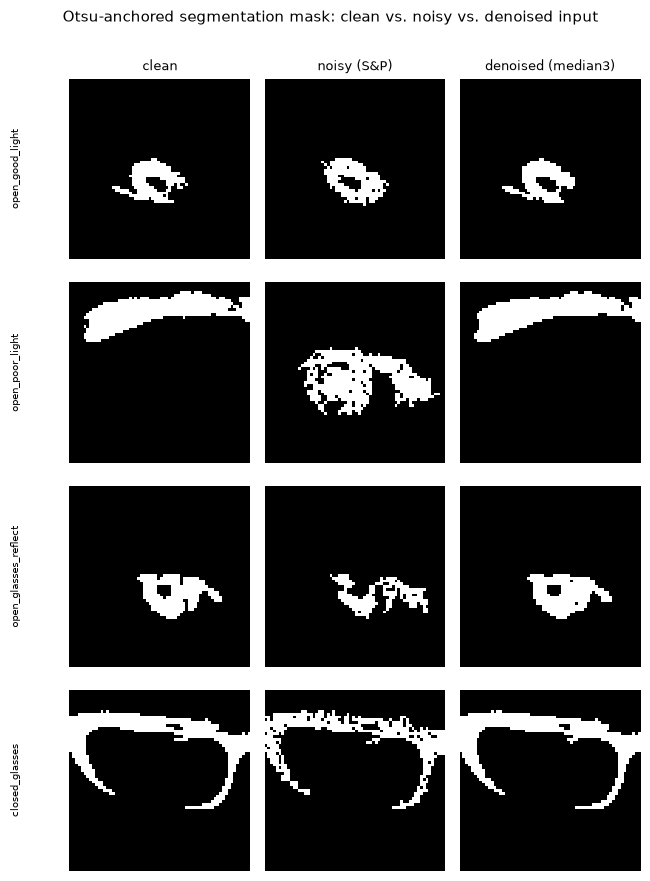

In [17]:
fig, axes = plt.subplots(len(seg_fig_panels), 3, figsize=(6.5, 2.2 * len(seg_fig_panels)))
for row, (name, sc, sn, sd) in enumerate(seg_fig_panels):
    for col, (label, seg) in enumerate([("clean", sc), ("noisy (S&P)", sn), ("denoised (median3)", sd)]):
        axes[row, col].imshow(seg.region_mask, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(label, fontsize=9)
    axes[row, 0].text(-0.3, 0.5, name, transform=axes[row, 0].transAxes, rotation=90, va="center", ha="center", fontsize=7)
fig.suptitle("Otsu-anchored segmentation mask: clean vs. noisy vs. denoised input", fontsize=11, y=1.0)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "task4_segmentation_impact.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** salt-and-pepper noise fragments the raw Otsu mask badly (component counts
jump from single digits on the clean image into the dozens/hundreds on the noisy image — each
surviving impulse speck below the pupil-anchored threshold becomes its own connected
component), and mask agreement with the clean image collapses (IoU as low as 0.00 on one
image — a real, honestly-reported failure, not smoothed over: on `open_poor_light` the
noisy-image Otsu threshold locked onto a *different* spurious region entirely, not merely a
noisier version of the true pupil). Denoising with median 3x3 before segmentation **recovers
component counts back to clean-image range and lifts IoU to 0.90-0.98 on all 4 images** —
directly confirming the assignment's objective that this filtering stage measurably improves
what the segmentation module receives.

## Conclusions and limitations

- **Task 2's headline finding matches the textbook expectation on salt-and-pepper** (median
  dominates, by a wide margin) and is **directionally consistent but closer than expected on
  Gaussian noise** (mean edges out median, but median remains competitive rather than falling
  clearly behind) — reported as measured, not smoothed over. Full numbers:
  `results/task4_summary_by_noise.csv`.
- **High-boost's `A=1` does not reduce to a mild sharpen** — it collapses to a near-black
  pure-edge image; the pixel-identical match to standard unsharp masking is at `A=2`, verified
  directly in this notebook rather than assumed.
- **Denoising measurably improves downstream segmentation** on this dataset: median-filtered
  input recovers Otsu-anchored mask agreement with the clean-image mask from as low as 0.00
  IoU (noisy) to 0.90+ IoU (denoised) across all 4 test images.
- **Honest limitations:** (1) one noise level per type was swept (`amount=0.05`,
  `sigma=25`), not a full parameter sweep — chosen to be clearly visible without destroying
  eye structure, but results at other noise strengths may shift the mean/median ranking on
  Gaussian noise. (2) 4 images is enough to avoid a single-case anecdote but is not a
  statistically powered sample — the per-image metric table (`task4_metrics_full.csv`) shows
  real image-to-image variation (e.g. the glasses/reflection image behaves differently from
  the other three). (3) The segmentation-impact section uses only salt-and-pepper noise +
  median 3x3 (the clearest win from Task 2), not every filter/noise combination — a deliberate
  scope cut to keep this section concise as specified. (4) Edge-preservation is a linear
  gradient-correlation measure; it does not penalize a uniformly-scaled-down edge map, only a
  mislocated or destroyed one — a filter could preserve structure while dampening true edge
  strength and still score well here.